In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict

In [2]:
import time
import sys

In [3]:
df=pd.read_csv("Balanced_cleaned_multi_asset_market_data.csv")

In [4]:
df.head()

,date,final_price,asset,7d_avg,30d_avg,daily_pct_change,volatility_7d,momentum_14d,trend_signal,price_zscore
0,2008-07-22,0.637351,gold,0.643441,0.630081,-0.450878,0.502569,5.500000,1,0.785980
1,2006-03-20,0.453747,gold,0.459645,0.461664,0.044394,0.204350,-6.477138,0,0.280029
2,2003-11-17,0.343308,gold,0.343128,0.337131,-0.455395,0.180989,8.299988,1,1.260717
3,2006-04-28,0.513440,gold,0.503850,0.484898,0.788651,0.541434,63.399963,1,1.930167
4,2005-05-20,-1.026856,silver,-1.023042,-1.018854,-0.746464,-1.139541,0.095000,0,-1.083492


In [5]:
df.drop(columns=['date','final_price'],inplace = True)

In [6]:
df.head()

,asset,7d_avg,30d_avg,daily_pct_change,volatility_7d,momentum_14d,trend_signal,price_zscore
0,gold,0.643441,0.630081,-0.450878,0.502569,5.500000,1,0.785980
1,gold,0.459645,0.461664,0.044394,0.204350,-6.477138,0,0.280029
2,gold,0.343128,0.337131,-0.455395,0.180989,8.299988,1,1.260717
3,gold,0.503850,0.484898,0.788651,0.541434,63.399963,1,1.930167
4,silver,-1.023042,-1.018854,-0.746464,-1.139541,0.095000,0,-1.083492


In [7]:
# appying one hot encoding
df=pd.get_dummies(df,columns=['asset'],dtype=int)

In [8]:
df.head()

,7d_avg,30d_avg,daily_pct_change,volatility_7d,momentum_14d,trend_signal,price_zscore,asset_bitcoin,asset_ethereum,asset_gold,asset_litecoin,asset_ripple,asset_silver
0,0.643441,0.630081,-0.450878,0.502569,5.500000,1,0.785980,0,0,1,0,0,0
1,0.459645,0.461664,0.044394,0.204350,-6.477138,0,0.280029,0,0,1,0,0,0
2,0.343128,0.337131,-0.455395,0.180989,8.299988,1,1.260717,0,0,1,0,0,0
3,0.503850,0.484898,0.788651,0.541434,63.399963,1,1.930167,0,0,1,0,0,0
4,-1.023042,-1.018854,-0.746464,-1.139541,0.095000,0,-1.083492,0,0,0,0,0,1


In [9]:
X=df.drop('trend_signal',axis=1)
Y=df['trend_signal']

In [10]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=43)

In [11]:
log_model = LogisticRegression(
    penalty='l2',          # Regularization type (L2 = Ridge)
    solver='lbfgs',        # Efficient for large datasets
    max_iter=2000,         # Ensure convergence
    C=1.0,                 # Regularization strength (lower = more regularization)
    n_jobs=-1              # Use all CPU cores
)


In [12]:
tree_model = DecisionTreeClassifier(
    criterion='gini',       # or 'entropy'
    max_depth=15,           # Limit tree depth for generalization
    min_samples_split=50,   # Minimum samples before split
    min_samples_leaf=20,    # Minimum samples per leaf node
    max_features='sqrt',    # Random subset of features per split
    random_state=42
)


In [13]:
rf_model = RandomForestClassifier(
    n_estimators=200,       # Number of trees (100–300 ideal)
    criterion='gini',
    max_depth=20,           # Limit depth for speed
    min_samples_split=50,
    min_samples_leaf=20,
    max_features='sqrt',
    bootstrap=True,         # Bootstrapping improves generalization
    n_jobs=-1,
    random_state=42
)


In [14]:
xgb_model = XGBClassifier(
    n_estimators=400,           # Number of boosting rounds
    learning_rate=0.05,         # Smaller = slower but better accuracy
    max_depth=8,                # Depth of individual trees
    subsample=0.8,              # Randomly sample 80% of training data per round
    colsample_bytree=0.8,       # Randomly sample 80% of features
    gamma=1,                    # Minimum loss reduction to make a split
    reg_lambda=1.5,             # L2 regularization
    reg_alpha=0.5,              # L1 regularization
    min_child_weight=5,         # Minimum instance weight per child
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)


In [15]:
models = [log_model, tree_model, rf_model, xgb_model]

In [16]:
results = []

In [17]:
# define cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for item in models:
    print(f"\n🔄 Training started for: {item.__class__.__name__}")
    bar_length = 30

    # Fake progress bar animation
    for i in range(bar_length + 1):
        progress = int((i / bar_length) * 100)

        # Color gradient (Red -> Yellow -> Green)
        if progress < 40:
            color = "\033[91m"  # Red
        elif progress < 80:
            color = "\033[93m"  # Yellow
        else:
            color = "\033[92m"  # Green

        reset = "\033[0m"
        bar = color + "█" * i + reset + "-" * (bar_length - i)
        sys.stdout.write(f"\rTraining : |{bar}| {progress}%")
        sys.stdout.flush()
        time.sleep(0.05)  # speed of bar filling

    item.fit(X_train,Y_train)

    print(f"\n✅ Cross-validation running for {item.__class__.__name__}...")

    # Perform cross-validation predictions
    y_pred = cross_val_predict(item, X, Y, cv=cv)

    # Compute metrics (weighted average for multi-class)
    acc = accuracy_score(Y, y_pred)
    prec = precision_score(Y, y_pred, average='weighted')
    rec = recall_score(Y, y_pred, average='weighted')
    f1 = f1_score(Y, y_pred, average='weighted')

    print(f"📊 Accuracy: {acc:.3f}, Precision: {prec:.3f}, Recall: {rec:.3f}, F1: {f1:.3f}")

    # Store results
    results.append({
        "Model": item.__class__.__name__,
        "Accuracy": round(acc, 3),
        "Precision": round(prec, 3),
        "Recall": round(rec, 3),
        "F1-Score": round(f1, 3)
    })

    print(f"✅ {item.__class__.__name__} cross-validated successfully!\n")
    time.sleep(0.5)


🔄 Training started for: LogisticRegression
Training : |██████████████████████████████| 100%
✅ Cross-validation running for LogisticRegression...
📊 Accuracy: 0.894, Precision: 0.894, Recall: 0.894, F1: 0.894
✅ LogisticRegression cross-validated successfully!


🔄 Training started for: DecisionTreeClassifier
Training : |██████████████████████████████| 100%
✅ Cross-validation running for DecisionTreeClassifier...
📊 Accuracy: 0.885, Precision: 0.885, Recall: 0.885, F1: 0.885
✅ DecisionTreeClassifier cross-validated successfully!


🔄 Training started for: RandomForestClassifier
Training : |██████████████████████████████| 100%
✅ Cross-validation running for RandomForestClassifier...
📊 Accuracy: 0.901, Precision: 0.901, Recall: 0.901, F1: 0.901
✅ RandomForestClassifier cross-validated successfully!


🔄 Training started for: XGBClassifier
Training : |██████████████████████████████| 100%
✅ Cross-validation running for XGBClassifier...
📊 Accuracy: 0.928, Precision: 0.928, Recall: 0.928, F1: 0.92

In [18]:
results_df = pd.DataFrame(results)
print(results_df)

                    Model  Accuracy  Precision  Recall  F1-Score
0      LogisticRegression     0.894      0.894   0.894     0.894
1  DecisionTreeClassifier     0.885      0.885   0.885     0.885
2  RandomForestClassifier     0.901      0.901   0.901     0.901
3           XGBClassifier     0.928      0.928   0.928     0.928


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree
from sklearn.decomposition import PCA


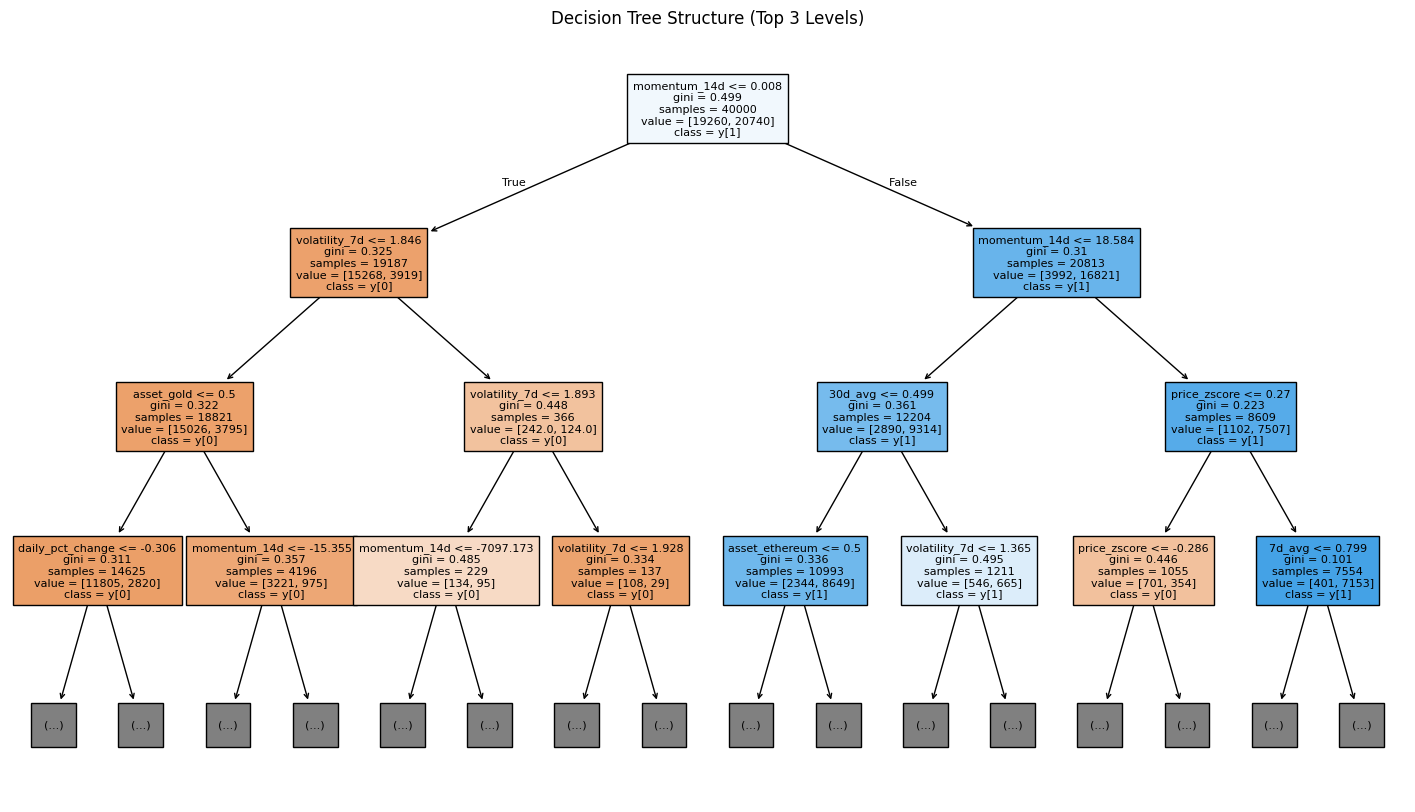

In [20]:
plt.figure(figsize=(18, 10))
plot_tree(tree_model,
          filled=True,
          feature_names=X.columns,
          class_names=True,
          max_depth=3,  # sirf pehle 3 levels dikhaye
          fontsize=8)
plt.title("Decision Tree Structure (Top 3 Levels)")
plt.show()


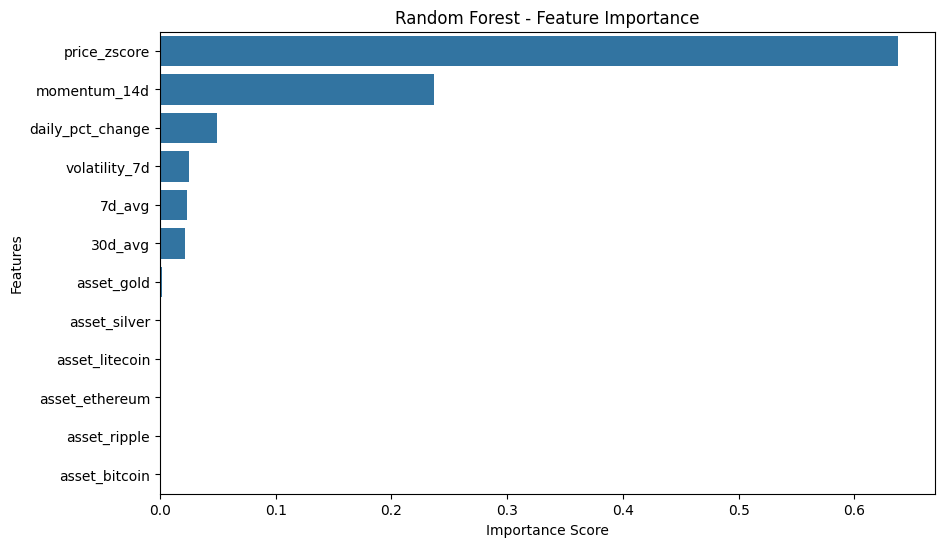

In [21]:
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=X.columns[indices])
plt.title("Random Forest - Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()


<Figure size 1000x600 with 0 Axes>

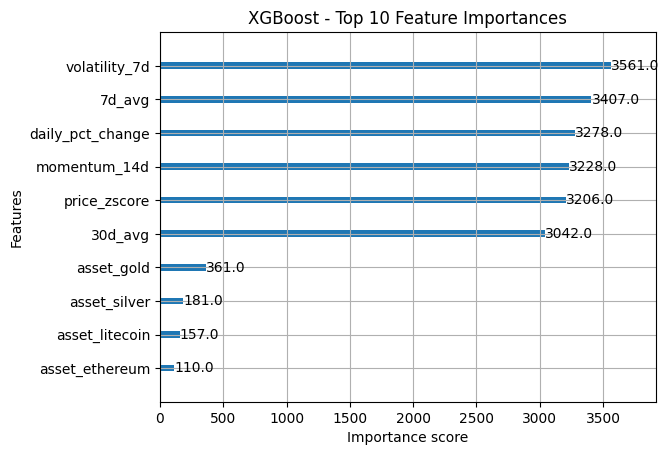

In [22]:
from xgboost import plot_importance

plt.figure(figsize=(10, 6))
plot_importance(xgb_model, max_num_features=10)
plt.title("XGBoost - Top 10 Feature Importances")
plt.show()


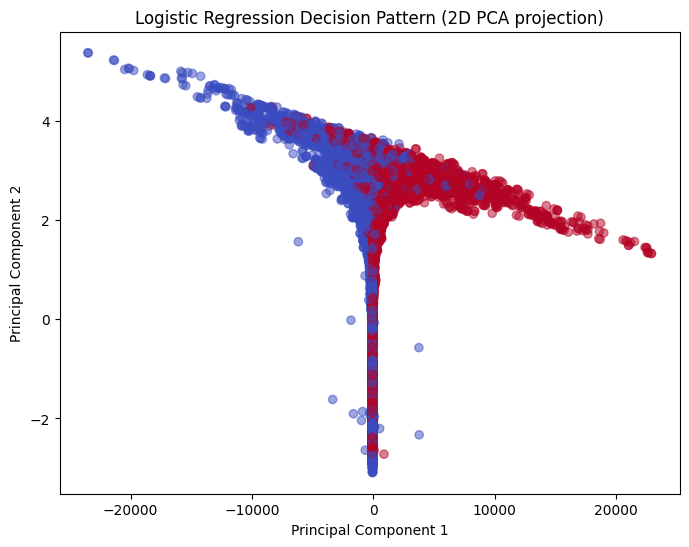

In [23]:
# Reduce to 2D using PCA (for visualization)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=Y, cmap='coolwarm', alpha=0.5)
plt.title("Logistic Regression Decision Pattern (2D PCA projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()


/tmp/ipython-input-4122656499.py:40: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


<Figure size 1400x700 with 0 Axes>

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


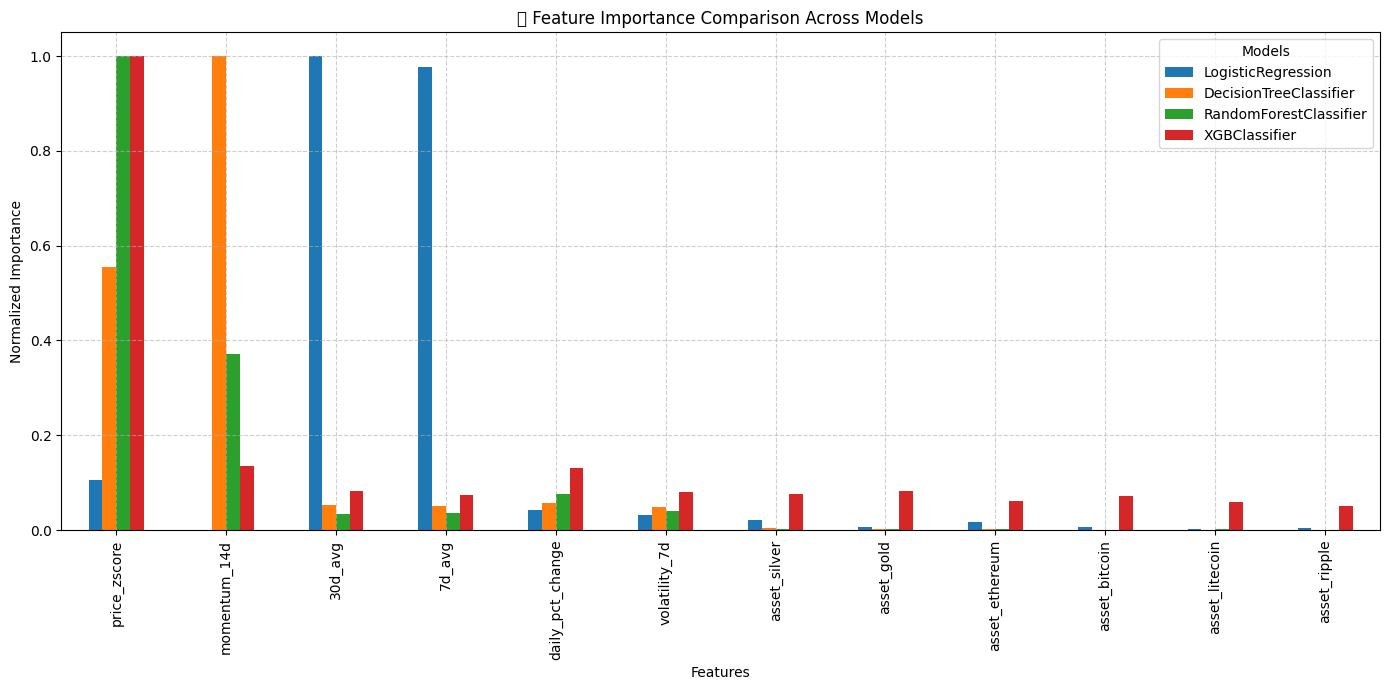

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Feature importance dictionary
feature_importances = pd.DataFrame(index=X.columns)

# Logistic Regression coefficients (absolute value = importance)
if hasattr(log_model, 'coef_'):
    feature_importances['LogisticRegression'] = np.abs(log_model.coef_[0])

# Decision Tree feature importance
if hasattr(tree_model, 'feature_importances_'):
    feature_importances['DecisionTreeClassifier'] = tree_model.feature_importances_

# Random Forest feature importance
if hasattr(rf_model, 'feature_importances_'):
    feature_importances['RandomForestClassifier'] = rf_model.feature_importances_

# XGBoost feature importance
if hasattr(xgb_model, 'feature_importances_'):
    feature_importances['XGBClassifier'] = xgb_model.feature_importances_

# Normalize each column so they are comparable
feature_importances = feature_importances / feature_importances.max()

# Sort by average importance
feature_importances['Average'] = feature_importances.mean(axis=1)
feature_importances = feature_importances.sort_values(by='Average', ascending=False).head(15)

# Plot comparison
plt.figure(figsize=(14, 7))
feature_importances.drop(columns=['Average']).plot(kind='bar', figsize=(14, 7))
plt.title("🔍 Feature Importance Comparison Across Models")
plt.xlabel("Features")
plt.ylabel("Normalized Importance")
plt.legend(title="Models")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


/tmp/ipython-input-1003991210.py:29: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


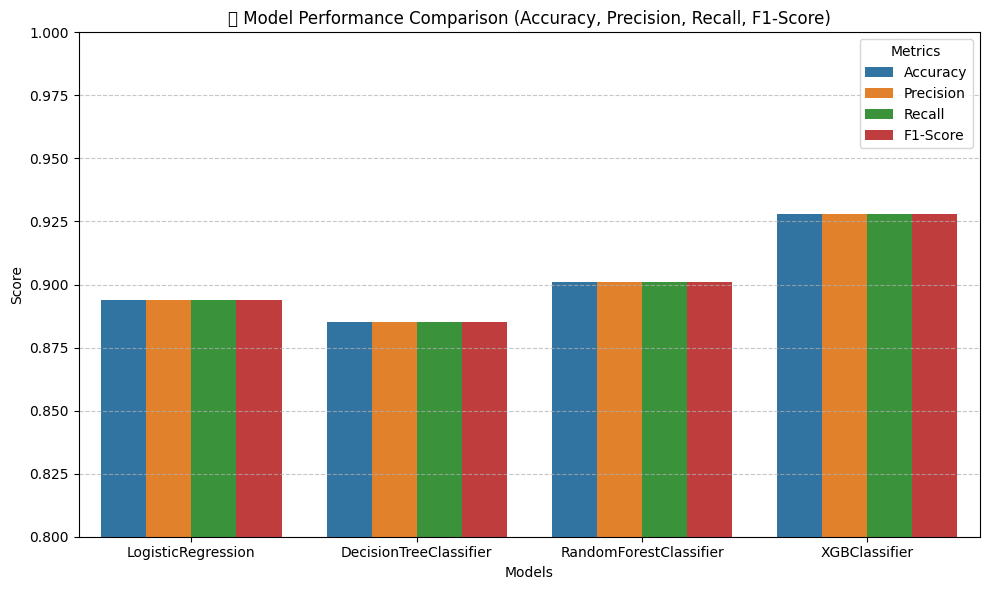

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your results DataFrame looks like this:
# results_df = pd.DataFrame(results)
# print(results_df)

# Set the plot size
plt.figure(figsize=(10, 6))

# Melt the DataFrame to long format for Seaborn
melted_df = results_df.melt(id_vars="Model",
                            value_vars=["Accuracy", "Precision", "Recall", "F1-Score"],
                            var_name="Metric",
                            value_name="Score")

# Create grouped bar plot
sns.barplot(data=melted_df, x="Model", y="Score", hue="Metric")

# Add chart details
plt.title("📊 Model Performance Comparison (Accuracy, Precision, Recall, F1-Score)")
plt.ylabel("Score")
plt.xlabel("Models")
plt.ylim(0.8, 1.0)  # adjust based on your score range
plt.legend(title="Metrics")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()


In [26]:
best_model = results_df.loc[results_df['F1-Score'].idxmax(), 'Model']
best_score = results_df['F1-Score'].max()
print(f"🏆 Best Model Overall: {best_model} (F1-Score: {best_score:.3f})")


🏆 Best Model Overall: XGBClassifier (F1-Score: 0.928)
